In [57]:
import pandas as pd
import numpy as np

from pathlib import Path

In [58]:
exam_result_folder = Path("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Grading/2026-02_Exam/")
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Grading/2026-02_Exam/1770295233__0__tst__results_137267.xlsx")

In [59]:
exam_results = pd.read_excel(exam_result_path)
exam_results.dropna(subset=["Login"],inplace=True, how="all")
exam_results.head()

,Name,Login,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,Average Time of Work,...,12_ScholarlyLiterature,12_LiteraturManagement,02_Matching_Definitions,07_Basics,03_Design-Plan,02_Correlation,03_Registered_Reports,06_Artifact_Outlier,08_Central_Limit_Theorem,11_Replication_Crisis
0,"Akdoğan, Melis",no73widi,80.0,85,passed,41,41,1.0,00:40:06,00:00:58,...,2,2,5,2,3,1,3.5,2,2.0,0
1,"Aslam, Benish",ib42upuj,82.0,85,passed,41,41,1.0,00:17:11,00:00:25,...,2,2,5,3,3,1,3.5,2,2.0,1
2,"Badarinath, Amogh",zu40pyxu,77.5,85,passed,41,41,1.0,00:47:08,00:01:08,...,2,2,5,3,3,1,3.5,2,2.0,1
3,"Bilal, Muhammad",ix51unyr,82.0,85,passed,41,41,1.0,00:40:36,00:00:59,...,2,2,5,3,3,1,4.0,2,2.0,1
4,"Choubisa, Lakshya",qo13towe,77.0,85,passed,41,41,1.0,00:37:25,00:00:54,...,2,2,5,3,3,1,4.0,2,2.0,0


In [60]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,Average Time of Work,First Visit,...,12_ScholarlyLiterature,12_LiteraturManagement,02_Matching_Definitions,07_Basics,03_Design-Plan,02_Correlation,03_Registered_Reports,06_Artifact_Outlier,08_Central_Limit_Theorem,11_Replication_Crisis
student_id,,,,,,,,,,,,,,,,,,,,,
no73widi,"Akdoğan, Melis",80.0,85,passed,41,41,1.0,00:40:06,00:00:58,"2. Feb 2026, 14:30",...,2,2,5,2,3,1,3.5,2,2.0,0
ib42upuj,"Aslam, Benish",82.0,85,passed,41,41,1.0,00:17:11,00:00:25,"2. Feb 2026, 14:30",...,2,2,5,3,3,1,3.5,2,2.0,1
zu40pyxu,"Badarinath, Amogh",77.5,85,passed,41,41,1.0,00:47:08,00:01:08,"2. Feb 2026, 14:31",...,2,2,5,3,3,1,3.5,2,2.0,1
ix51unyr,"Bilal, Muhammad",82.0,85,passed,41,41,1.0,00:40:36,00:00:59,"2. Feb 2026, 14:30",...,2,2,5,3,3,1,4.0,2,2.0,1
qo13towe,"Choubisa, Lakshya",77.0,85,passed,41,41,1.0,00:37:25,00:00:54,"2. Feb 2026, 14:30",...,2,2,5,3,3,1,4.0,2,2.0,0


<Axes: >

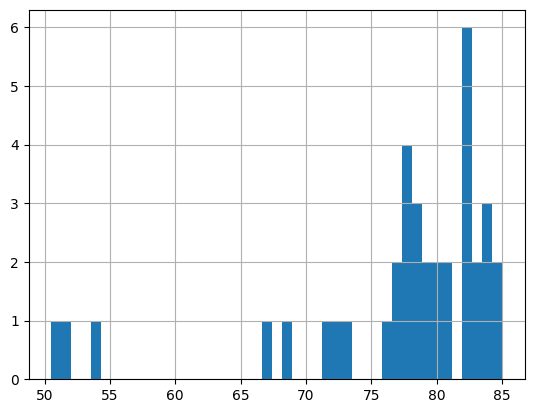

In [61]:
points = exam_results["Test Results in Points"]
points.hist(bins=45)

In [62]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
no73widi,80.0
ib42upuj,82.0
zu40pyxu,77.5
ix51unyr,82.0
qo13towe,77.0


In [63]:
pass_score = 50.0
max_score = 85.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

3.2

In [64]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [65]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[43.6, 46.8, 50.0, 53.2, 56.4, 59.6, 62.8, 66.0, 69.2, 72.4, 75.6, 78.8, 82.0]

In [66]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,78.8,85.0
1.33,75.6,78.7
1.66,72.4,75.5
2.00,69.2,72.3
2.33,66.0,69.1
2.66,62.8,65.9
3.00,59.6,62.7
3.33,56.4,59.5
3.66,53.2,56.3


In [67]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
no73widi,80.0,1.00
ib42upuj,82.0,1.00
zu40pyxu,77.5,1.33
ix51unyr,82.0,1.00
qo13towe,77.0,1.33
bu81xodi,79.5,1.00
ni04wyka,78.5,1.33
co07duri,82.5,1.00
uz59yqup,83.0,1.00


<Axes: xlabel='grade'>

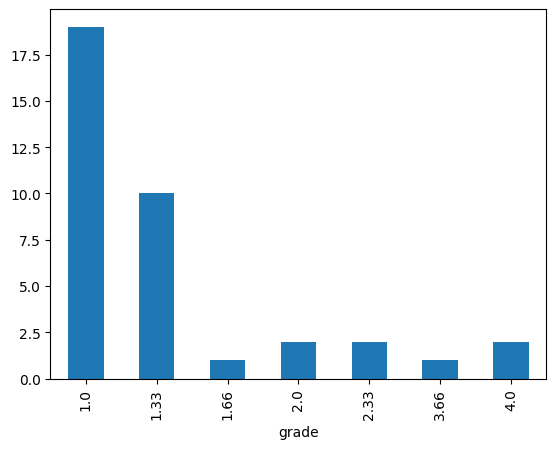

In [68]:
# Without Bonus

points["grade"].value_counts().sort_index().plot(kind="bar")

In [69]:
points["grade"].describe()

count    37.000000
mean      1.467027
std       0.817649
min       1.000000
25%       1.000000
50%       1.000000
75%       1.330000
max       4.000000
Name: grade, dtype: float64

In [70]:
bonus_points = pd.read_excel("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Exercise/WS25_26_Results/result_final.xlsx")
#rename column idm to identifier 
bonus_points.rename(columns={"idm":"student_id"}, inplace=True)
bonus_points.set_index("student_id", inplace=True)
bonus_points

,passed,bonus
student_id,,
av52ugaz,5,0.66
bu60fyhy,5,0.66
du23bera,1,0.00
ex22uwud,1,0.00
fe54pebo,3,0.00
ic51uciw,1,0.00
ic73elez,5,0.66
lo72fudi,2,0.00
ni04wyka,5,0.66


In [71]:
# join dataframes
points = points.join(bonus_points, how="left")
points.fillna(0, inplace=True)

#points.drop("student_id", axis=1, inplace=True)
points

,points,grade,passed,bonus
student_id,,,,
no73widi,80.0,1.00,4.0,0.33
ib42upuj,82.0,1.00,0.0,0.00
zu40pyxu,77.5,1.33,4.0,0.33
ix51unyr,82.0,1.00,0.0,0.00
qo13towe,77.0,1.33,0.0,0.00
bu81xodi,79.5,1.00,0.0,0.00
ni04wyka,78.5,1.33,5.0,0.66
co07duri,82.5,1.00,0.0,0.00
uz59yqup,83.0,1.00,0.0,0.00


In [72]:
points.drop("passed", axis=1, inplace=True)

In [73]:
points

,points,grade,bonus
student_id,,,
no73widi,80.0,1.00,0.33
ib42upuj,82.0,1.00,0.00
zu40pyxu,77.5,1.33,0.33
ix51unyr,82.0,1.00,0.00
qo13towe,77.0,1.33,0.00
bu81xodi,79.5,1.00,0.00
ni04wyka,78.5,1.33,0.66
co07duri,82.5,1.00,0.00
uz59yqup,83.0,1.00,0.00


In [74]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_25732/3924598343.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0
/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn

,points,grade,bonus,grade_with_bonus
student_id,,,,
no73widi,80.0,1.00,0.33,1.00
ib42upuj,82.0,1.00,0.00,1.00
zu40pyxu,77.5,1.33,0.33,1.00
ix51unyr,82.0,1.00,0.00,1.00
qo13towe,77.0,1.33,0.00,1.33
bu81xodi,79.5,1.00,0.00,1.00
ni04wyka,78.5,1.33,0.66,1.00
co07duri,82.5,1.00,0.00,1.00
uz59yqup,83.0,1.00,0.00,1.00


In [75]:
points = round(points, 1)
#points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
no73widi,80.0,1.0,0.3,1.0
ib42upuj,82.0,1.0,0.0,1.0
zu40pyxu,77.5,1.3,0.3,1.0
ix51unyr,82.0,1.0,0.0,1.0
qo13towe,77.0,1.3,0.0,1.3
bu81xodi,79.5,1.0,0.0,1.0
ni04wyka,78.5,1.3,0.7,1.0
co07duri,82.5,1.0,0.0,1.0
uz59yqup,83.0,1.0,0.0,1.0


In [76]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,37.000000,37.000000,37.000000,37.000000
mean,76.891892,1.459459,0.156757,1.372973
std,8.633056,0.820724,0.278429,0.784803
min,50.500000,1.000000,0.000000,1.000000
25%,77.000000,1.000000,0.000000,1.000000
50%,79.000000,1.000000,0.000000,1.000000
75%,82.500000,1.300000,0.300000,1.300000
max,85.000000,4.000000,0.700000,4.000000


<Axes: xlabel='grade_with_bonus'>

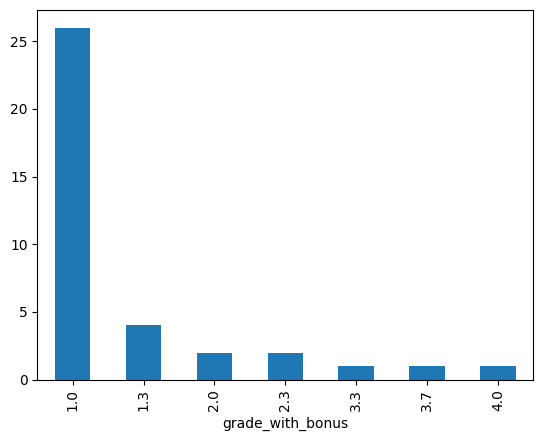

In [77]:
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [78]:
# save to csv
points.to_csv(exam_result_folder.joinpath("2026-02_BPOS_Exam_results_final.csv"))